In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental.ode import odeint
import matplotlib.pyplot as plt
from functools import partial # reduces arguments to function by making some subset implicit

from jax.example_libraries import stax
from jax.example_libraries import optimizers

# visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
# from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
from functools import partial
# import proglog
# from PIL import Image

from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

/tmp/ipykernel_146762/2740394483.py:20: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(xla_bridge.get_backend().platform)


gpu


In [ ]:
def equation_of_motion(lagrangian, state, frc, t=None):
  q, q_t = jnp.split(state, 2)
  q_tt = (jnp.linalg.pinv(jax.hessian(lagrangian, 1)(q, q_t, frc))
          @ (jax.grad(lagrangian, 0)(q, q_t, frc) + frc
             - jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t, frc) @ q_t))
  return jnp.concatenate([q_t, q_tt])

def solve_lagrangian(lagrangian, initial_state, **kwargs):
  # We currently run odeint on CPUs only, because its cost is dominated by
  # control flow, which is slow on GPUs.
  @partial(jax.jit, backend='cpu')
  def f(initial_state):
    return odeint(partial(equation_of_motion, lagrangian),
                  initial_state, **kwargs)
  return f(initial_state)

def normalize_dp(state):
  # wrap generalized coordinates to [-pi, pi]
  return jnp.concatenate([
    (state[:2] + 0.5) % (1) - 0.5,
    ((state[2] + jnp.pi) % (2 * jnp.pi) - jnp.pi)[None],
    state[3:]],
    )
#   return state

def rk4_step(f, x, t, h):
  # one step of runge-kutta integration
  k1 = h * f(x, t)
  k2 = h * f(x + k1/2, t + h/2)
  k3 = h * f(x + k2/2, t + h/2)
  k4 = h * f(x + k3, t + h)
  return x + 1/6 * (k1 + 2 * k2 + 2 * k3 + k4)

In [46]:
import pickle 

with open('block_simulation_data.pkl', 'rb') as f:
    block_data = pickle.load(f)

pos = block_data['position']
vel = block_data['velocity']
acc = block_data['acceleration']
forces = block_data['control']

permutation = jax.random.permutation(jax.random.PRNGKey(0), pos.shape[0])
pos = pos[permutation]
vel = vel[permutation]
acc = acc[permutation]
forces = forces[permutation]

train_test_split = int(0.8 * pos.shape[0])

x_train = jax.device_get(jnp.concatenate([pos[:train_test_split], vel[:train_test_split]], axis=1))
xt_train = jax.device_get(jnp.concatenate([vel[:train_test_split], acc[:train_test_split]], axis=1))
f_train = jax.device_get(forces[:train_test_split])

x_test = jax.device_get(jnp.concatenate([pos[train_test_split:], vel[train_test_split:]], axis=1))
xt_test = jax.device_get(jnp.concatenate([vel[train_test_split:], acc[train_test_split:]], axis=1))
f_test = jax.device_get(forces[train_test_split:])

In [47]:
x_train

array([[ 1.7797305e-01,  8.8176048e-01, -8.4432453e-02, -2.2754666e-01,
         3.1913910e+00,  1.3900539e-01],
       [ 4.3611857e-01,  1.9862324e+00,  3.9064503e-01,  4.2677972e-01,
         3.1719472e+00,  9.3569681e-02],
       [ 3.5774651e-01,  1.0626703e-01, -3.1933337e-02, -2.6588449e-03,
         2.8971911e-03, -1.1956812e-02],
       ...,
       [ 2.0294431e-01,  1.1667532e+00, -1.4828297e-01, -4.0388861e-01,
         1.6484138e+00,  1.3268894e-01],
       [ 2.8011599e-01,  2.0143995e+00,  3.5963851e-01,  5.5025411e-01,
        -1.1693898e-01,  3.2226431e-01],
       [ 2.1837457e-01,  5.8181638e-01, -1.0514785e-01, -2.2768418e-01,
         2.7893207e+00,  4.3463789e-02]], shape=(16000, 6), dtype=float32)

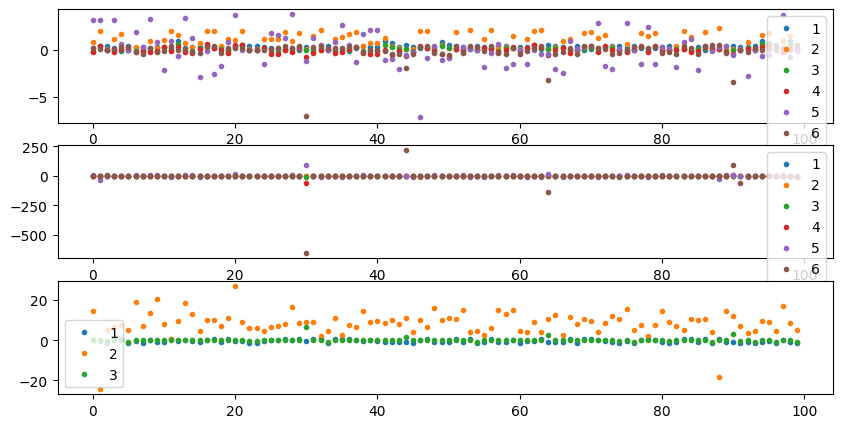

In [23]:
plt.figure(figsize=(10,5))
slc_idx = 100
plt.subplot(3,1,1)
plt.plot(x_train[:slc_idx,:], linestyle='None', marker='.')
plt.legend([1,2,3,4,5,6])

plt.subplot(3,1,2)
plt.plot(xt_train[:slc_idx,:], linestyle='None', marker='.')
plt.legend([1,2,3,4,5,6])

plt.subplot(3,1,3)
plt.plot(f_train[:slc_idx,:], linestyle='None', marker='.')
plt.legend([1,2,3])

In [24]:
# replace the lagrangian with a parameteric model
def learned_lagrangian(params):
  def lagrangian(q, q_t, frc):
    assert q.shape == (3,)
    state = normalize_dp(jnp.concatenate([q, q_t, frc]))
    return jnp.squeeze(nn_forward_fn(params, state), axis=-1)
  return lagrangian

@partial(jax.jit, static_argnums=())
def batch_dynamics(params, states, forces):
    def single_eom(x, f):
        q, q_t = jnp.split(x, 2)
        L = learned_lagrangian(params)
        # use jacfwd+grad instead of full hessian for a 3×3 mass matrix
        M   = jax.jacfwd(jax.grad(L, argnums=1), argnums=1)(q, q_t, f)
        dLdq = jax.grad(L, argnums=0)(q, q_t, f)
        C   = jax.jacfwd(jax.jacobian(L, argnums=1), argnums=0)(q, q_t, f)
        q_tt = jnp.linalg.solve(M, dLdq + f - C @ q_t)
        return jnp.concatenate([q_t, q_tt])
    return jax.vmap(single_eom)(states, forces)

@jax.jit
def loss(params, batch):
    states, targets, forces = batch
    preds = batch_dynamics(params, states, forces)
    return jnp.mean((preds - targets) ** 2)

# # define the loss of the model (MSE between predicted q, \dot q and targets)
# @jax.jit
# def loss(params, batch, time_step=None):
#   state, targets, forcing = batch
# #   if time_step is not None:
# #     f = partial(equation_of_motion, learned_lagrangian(params))
# #     preds = jax.vmap(partial(rk4_step, f, t=0.0, h=time_step))(state)
# #   else:
#   preds = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(state, forcing)
#   return jnp.mean((preds - targets) ** 2)

# # build a neural network model
# init_random_params, nn_forward_fn = stax.serial(
#     stax.Dense(128),
#     stax.Softplus,
#     stax.Dense(128),
#     stax.Softplus,
#     stax.Dense(1),
# )

init_random_params, nn_forward_fn = stax.serial(
    stax.Dense(256),
    stax.Softplus,
    stax.Dense(256),
    stax.Softplus,
    stax.Dense(256),
    stax.Softplus,
    stax.Dense(1),
)

In [51]:
@jax.jit
def update_timestep(i, opt_state, batch):
  params = get_params(opt_state)
  return opt_update(i, jax.grad(loss)(params, batch, time_step), opt_state)

@jax.jit
def update_derivative(i, opt_state, batch):
  params = get_params(opt_state)
  return opt_update(i, jax.grad(loss)(params, batch, None), opt_state)

x_train = jax.device_put(jax.vmap(normalize_dp)(x_train))
# y_train = jax.device_put(y_train)

x_test = jax.device_put(jax.vmap(normalize_dp)(x_test))
# y_test = jax.device_put(y_test)

In [54]:
x_train[0,:]

Array([ 0.17797303, -0.11823952, -0.08443236, -0.08443245, -0.22754666,
        3.191391  ,  0.1390054 ], dtype=float32)

In [42]:
%%time

rng = jax.random.PRNGKey(0)
_, init_params = init_random_params(rng, (-1, 9))

# numbers in comments denote stephan's settings
batch_size = 100
test_every = 10
num_batches = 1500

train_losses = []
test_losses = []

# adam w learn rate decay
opt_init, opt_update, get_params = optimizers.adam(
    lambda t: jnp.select([t < batch_size*(num_batches//3),
                          t < batch_size*(2*num_batches//3),
                          t > batch_size*(2*num_batches//3)],
                         [1e-2, 3e-4, 1e-4]))
opt_state = opt_init(init_params)

for iteration in range(batch_size*num_batches + 1):
  if iteration % batch_size == 0:
    params = get_params(opt_state)
    train_loss = loss(params, (x_train, xt_train, f_train))
    train_losses.append(train_loss)
    test_loss = loss(params, (x_test, xt_test, f_test))
    test_losses.append(test_loss)
    if iteration % (batch_size*test_every) == 0:
      print(f"iteration={iteration}, train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")
  opt_state = update_derivative(iteration, opt_state, (x_train, xt_train, f_train))

params = get_params(opt_state)

iteration=0, train_loss=754731968.000000, test_loss=777978368.000000
iteration=1000, train_loss=552311.625000, test_loss=470894.750000
iteration=2000, train_loss=425159.062500, test_loss=469466.968750
iteration=3000, train_loss=361318.937500, test_loss=476924.531250
iteration=4000, train_loss=323057.968750, test_loss=494832.968750
iteration=5000, train_loss=298410.062500, test_loss=525256.687500
iteration=6000, train_loss=278681.031250, test_loss=582521.000000
iteration=7000, train_loss=264018.468750, test_loss=703751.687500
iteration=8000, train_loss=254934.781250, test_loss=913982.000000
iteration=9000, train_loss=249358.156250, test_loss=1239272.375000
iteration=10000, train_loss=245006.078125, test_loss=1558580.250000
iteration=11000, train_loss=240388.265625, test_loss=1779910.000000
iteration=12000, train_loss=234333.046875, test_loss=1909144.750000
iteration=13000, train_loss=225945.515625, test_loss=2081658.875000
iteration=14000, train_loss=214088.453125, test_loss=2342970.250

In [45]:
# %%time
import optax
from optax import exponential_decay
from optax.schedules import sgdr_schedule

rng = jax.random.PRNGKey(0)
_, init_params = init_random_params(rng, (-1, 9))

# numbers in comments denote stephan's settings
batch_size = 100
test_every = 10
num_batches = 1500

train_losses = []
test_losses = []

# lr_schedule = exponential_decay(
#   init_value=1e-1,           # start LR
#   transition_steps=1000,     # how many steps per decay
#   decay_rate=0.9,            # multiply by 0.9 each “transition”
#   end_value=1e-4             # never go below this
# )                            # :contentReference[oaicite:0]{index=0}

total_steps = batch_size * num_batches
n_cycles    = 5
cycle_len   = total_steps // n_cycles

# build one dict per restart cycle:
c_kwargs = [{
    "init_value": 1e-1,       # start LR of this cycle
    "peak_value": 1e-2,       # same as init_value → no warmup
    "warmup_steps": 2,        # skip warmup
    "decay_steps": cycle_len, # cosine decay length
    "end_value": 1e-3,         # final LR = 0
} for _ in range(n_cycles)]

lr_schedule = sgdr_schedule(cosine_kwargs=c_kwargs)

optimizer = optax.adamw(
  learning_rate=lr_schedule,
  weight_decay=1e-2
)

opt_state = optimizer.init(init_params)
params = init_params

@jax.jit                                  # ③ one unified train step
def train_step(params, opt_state, batch):
  grads   = jax.grad(loss)(params, batch)
  updates, opt_state = optimizer.update(grads, opt_state, params)
  params  = optax.apply_updates(params, updates)
  return params, opt_state

for iteration in range(batch_size*num_batches + 1):
  if iteration % batch_size == 0:
    # params = get_params(opt_state)
    train_loss = loss(params, (x_train, xt_train, f_train))
    train_losses.append(train_loss)
    test_loss = loss(params, (x_test, xt_test, f_test))
    test_losses.append(test_loss)
    if iteration % (batch_size*test_every) == 0:
      print(f"iteration={iteration}, train_loss={train_loss:.6f}, test_loss={test_loss:.6f}, lr={lr_schedule(iteration):.6f}")
#   opt_state = update_derivative(iteration, opt_state, (x_train, xt_train, f_train))
    params, opt_state = train_step(params, opt_state, (x_train, xt_train, f_train))

# params = get_params(opt_state)

ValueError: array split does not result in an equal division: rest is 1

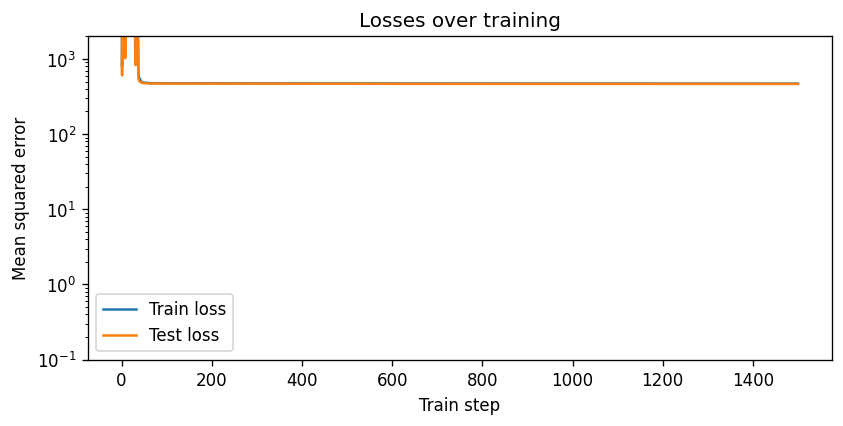

In [ ]:
plt.figure(figsize=(8, 3.5), dpi=120)
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.yscale('log')
plt.ylim(None, 2000)
plt.title('Losses over training')
plt.xlabel("Train step") ; plt.ylabel("Mean squared error")
plt.legend() ; plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_146762/961659018.py:5: SyntaxWarning: invalid escape sequence '\d'
  axes[0].set_title('Predicting $\dot q$')
/tmp/ipykernel_146762/961659018.py:6: SyntaxWarning: invalid escape sequence '\d'
  axes[0].set_xlabel('$\dot q$ actual')
/tmp/ipykernel_146762/961659018.py:7: SyntaxWarning: invalid escape sequence '\d'
  axes[0].set_ylabel('$\dot q$ predicted')
/tmp/ipykernel_146762/96

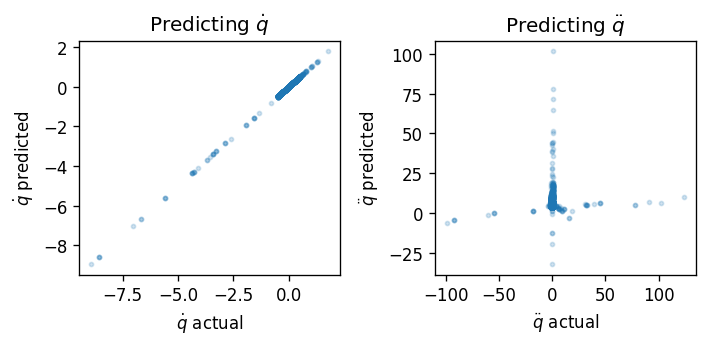

In [20]:
xt_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(x_test[], f_test)

fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=120)
axes[0].scatter(xt_test[:, 2], xt_pred[:, 2], s=6, alpha=0.2)
axes[0].set_title('Predicting $\dot q$')
axes[0].set_xlabel('$\dot q$ actual')
axes[0].set_ylabel('$\dot q$ predicted')
axes[1].scatter(xt_test[:, 3], xt_pred[:, 3], s=6, alpha=0.2)
axes[1].set_title('Predicting $\ddot q$')
axes[1].set_xlabel('$\ddot q$ actual')
axes[1].set_ylabel('$\ddot q$ predicted')
plt.tight_layout()

In [49]:
# make a meshgrid of possible angles
angle_range = -np.pi + 2 * np.pi * np.arange(100)/100
x_scanned = np.stack(np.meshgrid(angle_range, angle_range, [0.0], [0.0], indexing='ij'), axis=-1).reshape(-1, 4)

%time xt_actual = jax.vmap(f_analytical)(x_scanned) # actual time derivatives

CPU times: user 38.2 ms, sys: 3.8 ms, total: 42 ms
Wall time: 29.1 ms


In [50]:
%time xt_predicted = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(x_scanned) # predicted time derivatives

CPU times: user 6.06 s, sys: 154 ms, total: 6.21 s
Wall time: 3.21 s


Colorscale is \dot theta1


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_107300/1882305494.py:8: SyntaxWarning: invalid escape sequence '\d'
  print("Colorscale is \dot theta1")


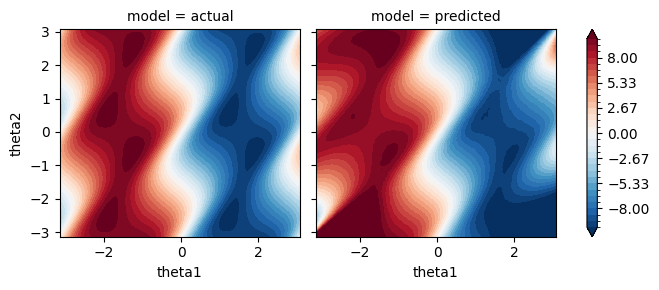

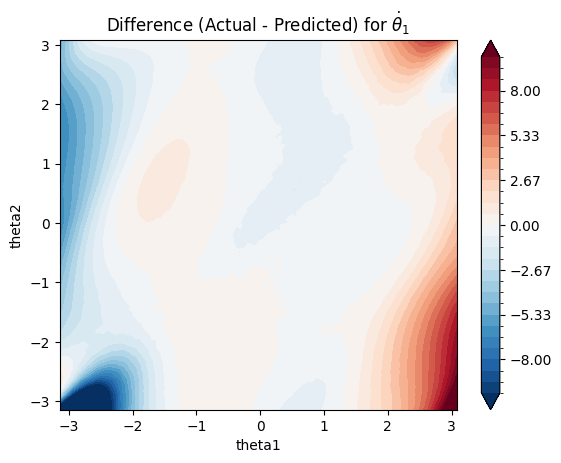

In [51]:
import xarray
dataarray = xarray.DataArray(np.stack([xt_actual.reshape(100, 100, 4),
                                       xt_predicted.reshape(100, 100, 4)]),
                             dims=['model', 'theta1', 'theta2', 'time_derivative'],
                             coords={'model': ['actual', 'predicted'], 'theta1': angle_range, 'theta2': angle_range})

dataarray.isel(time_derivative=2).plot.contourf(cmap='RdBu_r', levels=31, col='model', x='theta1', y='theta2', vmin=-10, vmax=10)
print("Colorscale is \dot theta1")
plt.show()

# Calculate the difference (actual - predicted)
difference = dataarray.sel(model='actual') - dataarray.sel(model='predicted')
# Plot the difference for time_derivative=2
difference.isel(time_derivative=2).plot.contourf(levels=31, x='theta1', y='theta2', vmin=-10, vmax=10,cmap='RdBu_r')

plt.title('Difference (Actual - Predicted) for $\\dot{\\theta}_1$')
# plt.colorbar(label='Difference in $\\dot{\\theta}_1$')
plt.show()